In [1]:
print("Hello Sindhu")

Hello Sindhu


# Project 01 – Exploratory Data Analysis (EDA)

**Dataset:** Netflix Movies & TV Shows Dataset

**Name:** Sindhu Chirumamilla

**Internship:** Pluto Academy AI & ML Internship Program

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df.duplicated().sum()

np.int64(0)

# Project 01 - Exploratory Data Analysis (EDA)

## Dataset: Netflix Movies & TV Shows

### Step 1: Load and Inspect the Data

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [16]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed", errors="coerce")

In [17]:
df["year_added"] = df["date_added"].dt.year

In [18]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


In [19]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


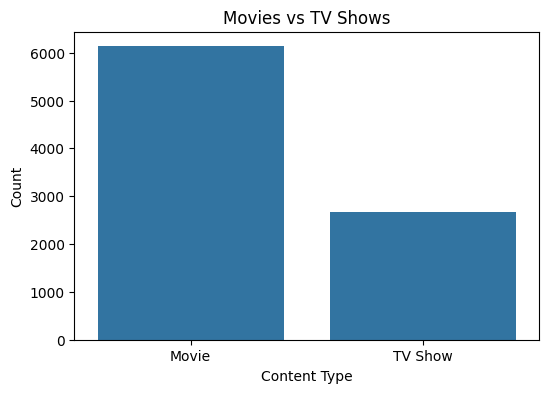

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Question 1: How many Movies and TV Shows are available on Netflix?

**Observation:**
- Movies: 6131
- TV Shows: 2676

**Conclusion:**
Netflix has significantly more Movies than TV Shows.

In [35]:
df["country"].value_counts().head(10)


,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


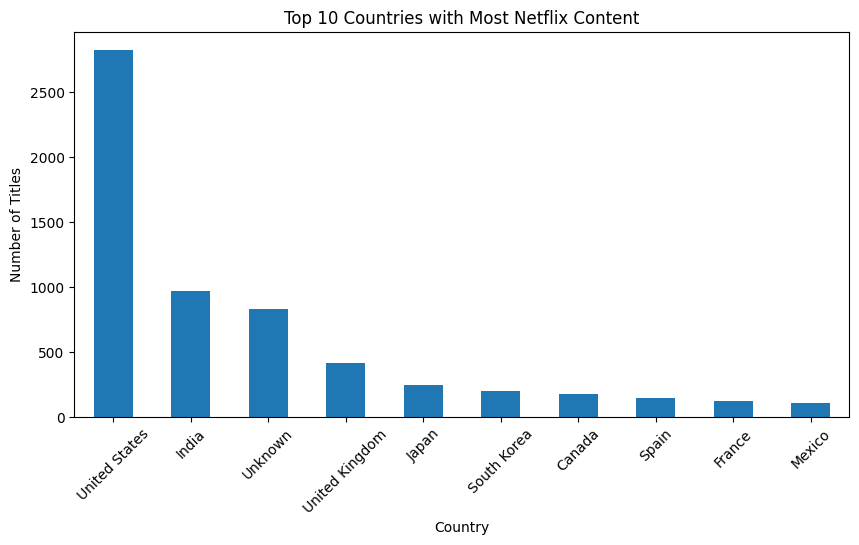

In [36]:
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Question 2: Which countries have the most Netflix content?

**Observation:**
The top 10 countries with the highest number of Netflix titles are:

- United States – 2818
- India – 972
- Unknown – 831
- United Kingdom – 419
- Japan – 245
- South Korea – 199
- Canada – 181
- Spain – 145
- France – 124
- Mexico – 110

**Conclusion:**
The United States has the highest number of Netflix titles, followed by India.

In [23]:
df["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


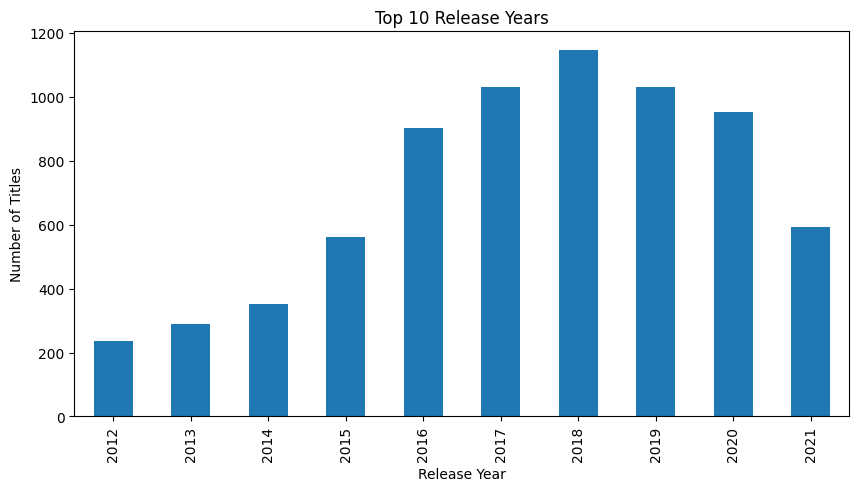

In [24]:
plt.figure(figsize=(10,5))
df["release_year"].value_counts().head(10).sort_index().plot(kind="bar")
plt.title("Top 10 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Question 3: Which release years have the most Netflix titles?

**Observation:**

- 2018 – 1147
- 2017 – 1032
- 2019 – 1030
- 2020 – 953
- 2016 – 902
- 2021 – 592
- 2015 – 560
- 2014 – 352
- 2013 – 288
- 2012 – 237

**Conclusion:**
Most Netflix titles were released between 2016 and 2020, with 2018 having the highest number of releases.

In [25]:
df["rating"].value_counts()

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


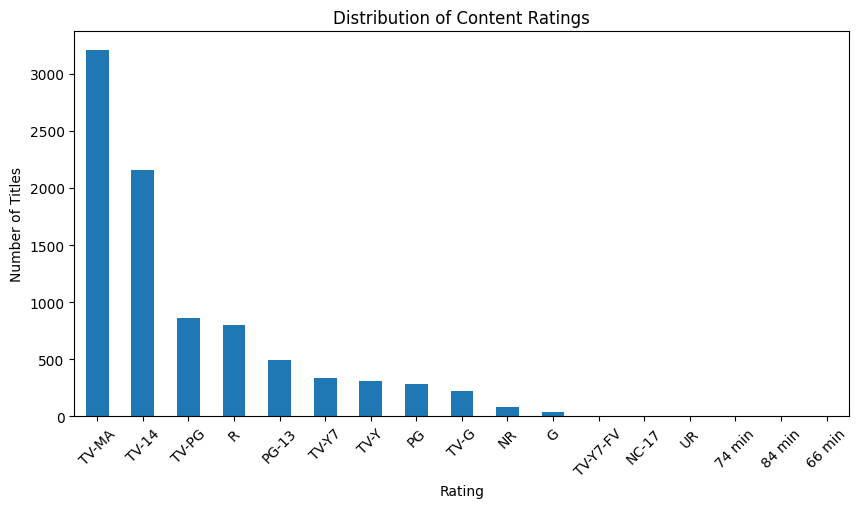

In [26]:
plt.figure(figsize=(10,5))
df["rating"].value_counts().plot(kind="bar")
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Question 4: Which content ratings are most common on Netflix?

**Observation:**

- TV-MA – 3211
- TV-14 – 2160
- TV-PG – 863
- R – 799
- PG-13 – 490

**Conclusion:**
TV-MA is the most common content rating on Netflix, indicating that a large portion of the content is intended for mature audiences.

In [27]:
df["listed_in"].str.split(", ").explode().value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


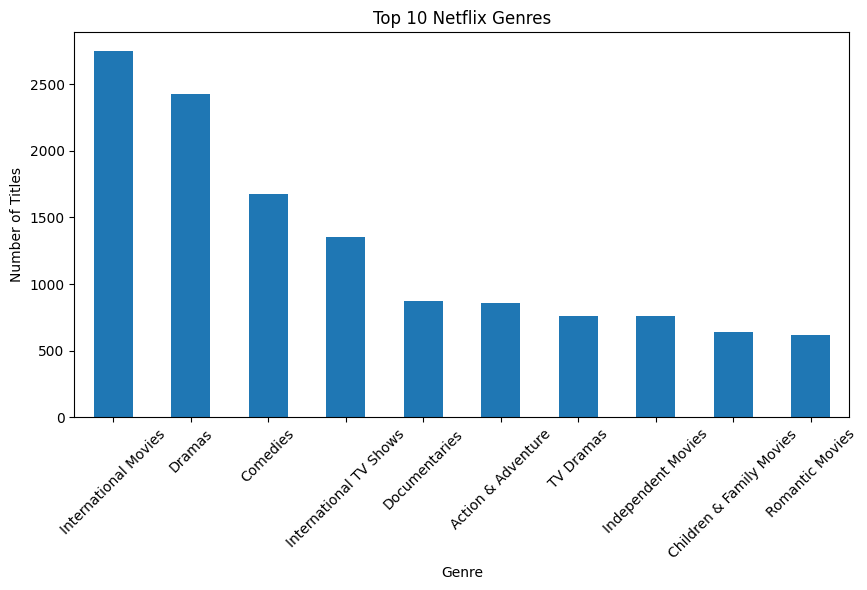

In [28]:
plt.figure(figsize=(10,5))
df["listed_in"].str.split(", ").explode().value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### Question 5: Which genres are most common on Netflix?

**Observation:**

- International Movies – 2752
- Dramas – 2427
- Comedies – 1674
- International TV Shows – 1351
- Documentaries – 869
- Action & Adventure – 859
- TV Dramas – 763
- Independent Movies – 756
- Children & Family Movies – 641
- Romantic Movies – 616

**Conclusion:**
International Movies are the most common genre on Netflix, followed by Dramas and Comedies.

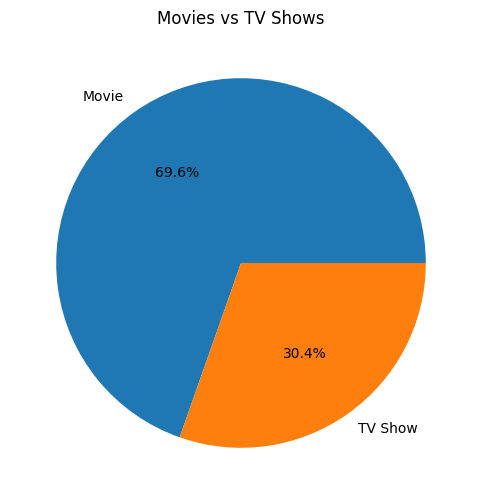

In [29]:
plt.figure(figsize=(6,6))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

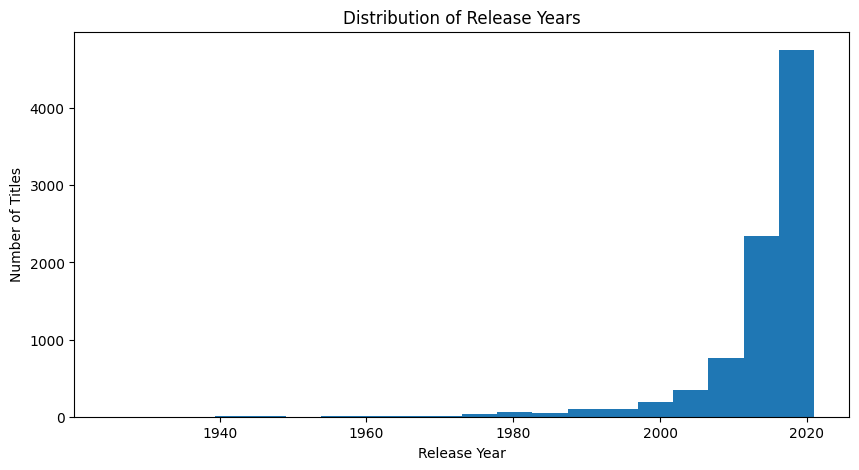

In [30]:
plt.figure(figsize=(10,5))

plt.hist(df["release_year"], bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

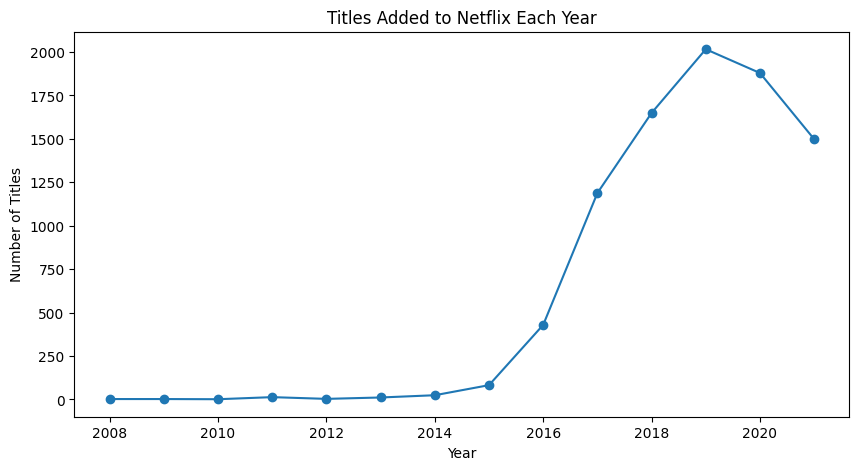

In [31]:
year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year.index, year.values, marker="o")

plt.title("Titles Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

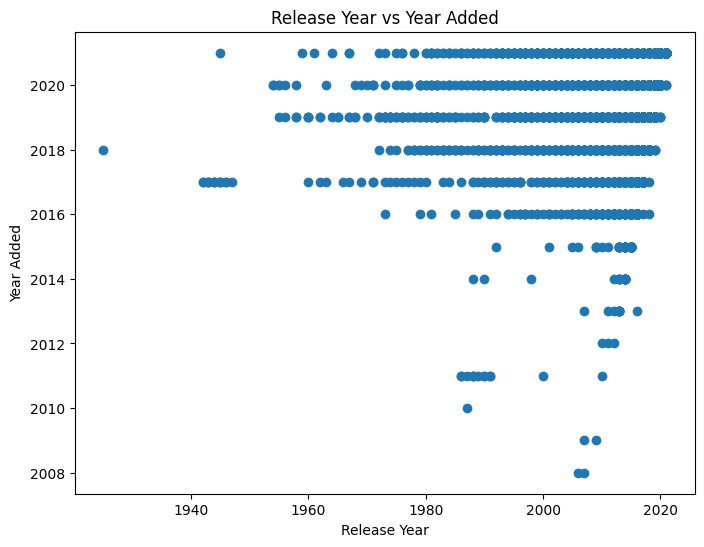

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(df["release_year"], df["year_added"])

plt.title("Release Year vs Year Added")
plt.xlabel("Release Year")
plt.ylabel("Year Added")

plt.show()

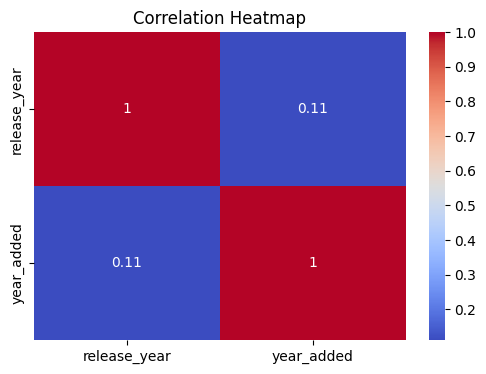

In [33]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(6,4))

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Business Insights

### 1. Movies dominate Netflix's content library.
The analysis shows that Netflix has 6,131 Movies compared to 2,676 TV Shows. This indicates that the platform focuses more on movies than television series.

### 2. The United States contributes the highest number of titles.
The United States has the largest content library on Netflix, followed by India. This suggests that these countries are major content producers for the platform.

### 3. Most Netflix titles were released between 2016 and 2020.
The highest number of releases occurred in 2018, showing that Netflix rapidly expanded its content during this period.

### 4. Mature audience content is the most common.
TV-MA is the most frequent content rating, indicating that Netflix mainly targets adult audiences.

### 5. International Movies are the most popular genre.
International Movies, Dramas, and Comedies are the top three genres, showing that Netflix offers a wide variety of content from different countries.

## Most Surprising Finding

The most surprising finding was that Netflix contains far more Movies than TV Shows. I also noticed that International Movies are the largest genre on the platform, showing Netflix's strong focus on global content. Another interesting observation was that most titles were released between 2016 and 2020, reflecting a period of rapid content growth.

## Conclusion

This project explored the Netflix Movies and TV Shows dataset using Exploratory Data Analysis (EDA). The data was cleaned, analyzed, and visualized to identify important trends. The analysis revealed that Movies dominate Netflix's catalog, the United States contributes the most content, TV-MA is the most common rating, and International Movies are the leading genre. These findings provide valuable insights into Netflix's content distribution and audience focus.

## Thank You

Thank you for reviewing my project. This notebook demonstrates data cleaning, exploratory data analysis, visualization, and business insights using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.